# Slonczewski STT Extension

Example 2 taken from the Mumax3 Website

https://mumax.github.io/examples.html


Flipping the magnetization of a elliptical nanodisk with Slonczewski STT.

Implemented by Jed Cheng (jed.cheng@mag.ed.kyushu-u.ac.jp)

In [1]:
# !pip install -q magnumnp numpy==1.22.4

2024-02-02 12:22:35  magnum.np:INFO magnum.np 1.1.4
2024-02-02 12:22:35  magnum.np:INFO [State] running on device: cuda:0 (dtype = float32)
2024-02-02 12:22:35  magnum.np:INFO [Mesh] 64x32x1 (size= 2.5e-09 x 2.5e-09 x 5e-09)


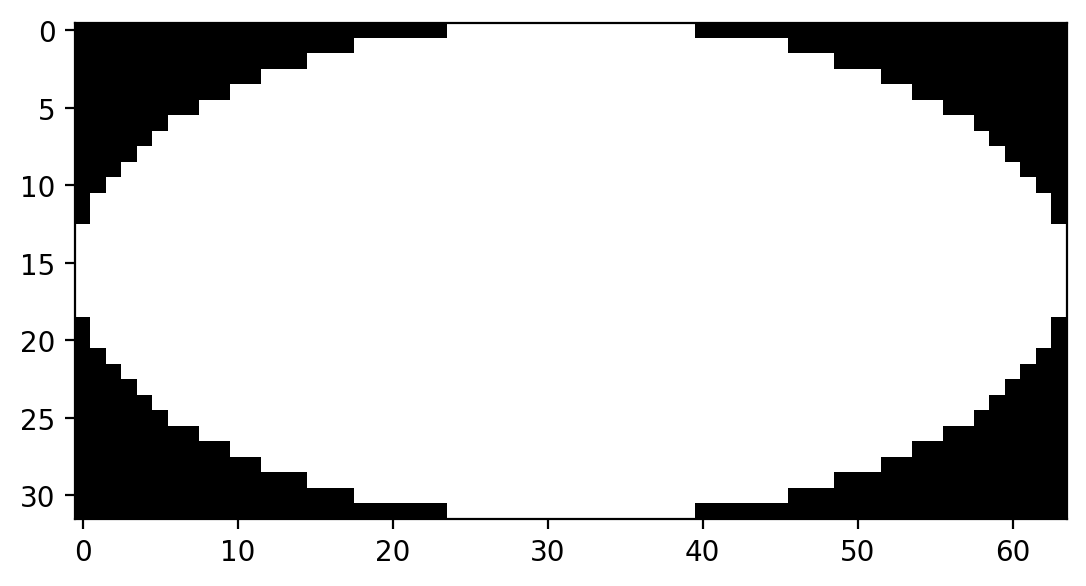

2024-02-02 12:22:35  magnum.np:INFO [LLGSolver] using RKF45 solver (atol = 1e-05)
2024-02-02 12:22:35  magnum.np:INFO [DEMAG]: Time calculation of demag kernel = 0.13144874572753906 s
2024-02-02 12:22:38  magnum.np:INFO [LLG] step: dt= 5e-12  t=5e-12
2024-02-02 12:22:39  magnum.np:INFO [LLG] step: dt= 5e-12  t=1e-11
2024-02-02 12:22:39  magnum.np:INFO [LLG] step: dt= 5e-12  t=1.5e-11
2024-02-02 12:22:39  magnum.np:INFO [LLG] step: dt= 5e-12  t=2e-11
2024-02-02 12:22:39  magnum.np:INFO [LLG] step: dt= 5e-12  t=2.5e-11
2024-02-02 12:22:39  magnum.np:INFO [LLG] step: dt= 5e-12  t=3e-11
2024-02-02 12:22:39  magnum.np:INFO [LLG] step: dt= 5e-12  t=3.5e-11
2024-02-02 12:22:39  magnum.np:INFO [LLG] step: dt= 5e-12  t=4e-11
2024-02-02 12:22:39  magnum.np:INFO [LLG] step: dt= 5e-12  t=4.5e-11
2024-02-02 12:22:39  magnum.np:INFO [LLG] step: dt= 5e-12  t=5e-11
2024-02-02 12:22:39  magnum.np:INFO [LLG] step: dt= 5e-12  t=5.5e-11
2024-02-02 12:22:39  magnum.np:INFO [LLG] step: dt= 5e-12  t=6e-11
20


TIMER REPORT
Operation                      No of calls    Avg time [ms]    Total time [s]
---------------------------  -------------  ---------------  ----------------
LLGSolver.step                         200        96.383            19.2766
    DemagField.h                     16890         0.512128          8.64983
    ExchangeField.h                  16890         0.253724          4.2854
    SpinTorqueSlonczewski.h          16890         0.12129           2.04858
---------------------------  -------------  ---------------  ----------------
Total                                                               20.0372
Missing                                                              0.760606



In [2]:
from magnumnp import *
import torch
import math


import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

import numpy as np

Timer.enable()


precision = torch.float32
torch.set_default_dtype(precision)

# initialize state
lx = 160e-9  # x dimension of the sample(m)
ly = 80e-9  # y dimension of the sample (m)
lz = 5e-9  # sample thickness (m)
dx = (2.5e-9, 2.5e-9, 5e-9)
n = (int(lx/dx[0]), int(ly/dx[1]), int(lz/dx[2]))
mesh = Mesh(n, dx)



state = State(mesh)
state.material = {
    "Ms": 8e5,
    "A": 1.3e-11,
    "alpha": 0.01,
    "P": 0.5669,
    "Lambda": 1,
    "gamma0": 2.211e5,
    "epsilon_prime": 0,
    "p": state.Tensor((math.cos(math.radians(20)), 
                       math.sin(math.radians(20)), 0)),
    "d": lz,
    "J": -8e11,

    }


state.m = state.Constant([0,0,0])


def Ms_fun(pos):


    x, y, z = pos[0]/1e-9, pos[1]/1e-9, pos[2]/1e-9


    a = 80
    b = 40
    h = 80
    w = 40

    if (x - h)**2/a**2 + (y - w)**2/b**2 <= 1:
        return 1
    
    return 0




empty = 0
total = n[0]*n[1]*n[2]
for i in range(n[0]):
    for j in range(n[1]):
        for k in range(n[2]):
            x = i*dx[0] + dx[0]/2
            y = j*dx[1] + dx[1]/2
            z = k*dx[2] + dx[2]/2

            # state.m[i,j,k,0] = Ms_fun((x,y,z))
            if Ms_fun((x,y,z)) == 1:
                state.m[i,j,k,0] = 1
            else:
                empty += 1


plt.imshow(state.m[:,:,0,0].cpu().numpy().T, cmap="gray")
# plt.savefig("init.png", dpi=300)
plt.show()
# plt.close()


# state.Slonczewski = True # enable slonczewski spin torque

# initialize field terms
demag    = DemagField()
exchange = ExchangeField()
torque  = SpinTorqueSlonczewski(state)


# perform integration with spin torque
llg = LLGSolver([demag, exchange, torque])
logger = Logger("data", ['t', 'm'], ["m"])
while state.t < 1e-9:
    llg.step(state, 5e-12)
    logger << state

Timer.print_report()




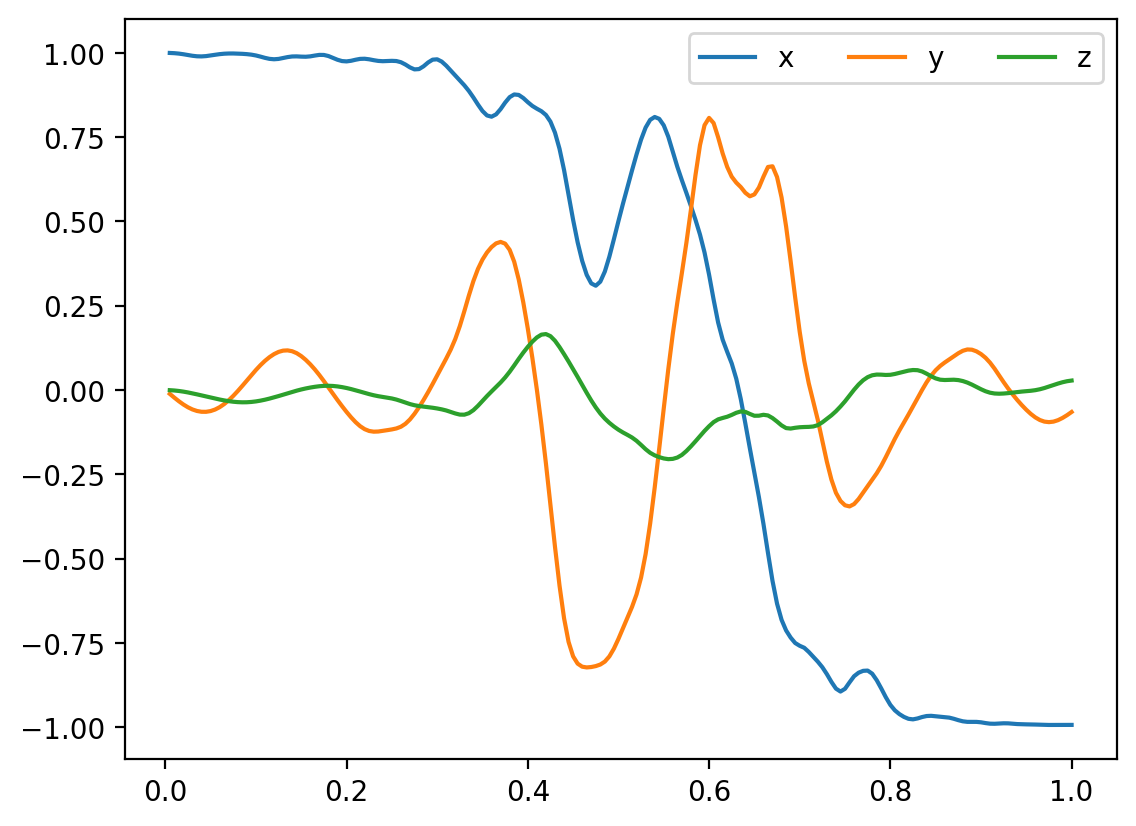

In [3]:
data = np.loadtxt("data/log.dat")

t = data[:,0]
mx = data[:,1] / (1 - empty/total)
my = data[:,2] / (1 - empty/total)
mz = data[:,3] / (1 - empty/total)


plt.plot(t*1e9, mx, label = "x")
plt.plot(t*1e9, my, label = "y")
plt.plot(t*1e9, mz, label = "z")
plt.legend(ncol=3)
plt.show()

## Plot Results

In [4]:
from os import path
if not path.isdir("ref"):
    !mkdir ref
    !wget -P ref https://gitlab.com/jedcheng/magnum.np/raw/main/demos/slonczewski/ref/M_mx3_2.npy
    !wget -P ref https://gitlab.com/jedcheng/magnum.np/raw/main/demos/slonczewski/ref/M_oommf_2.npy

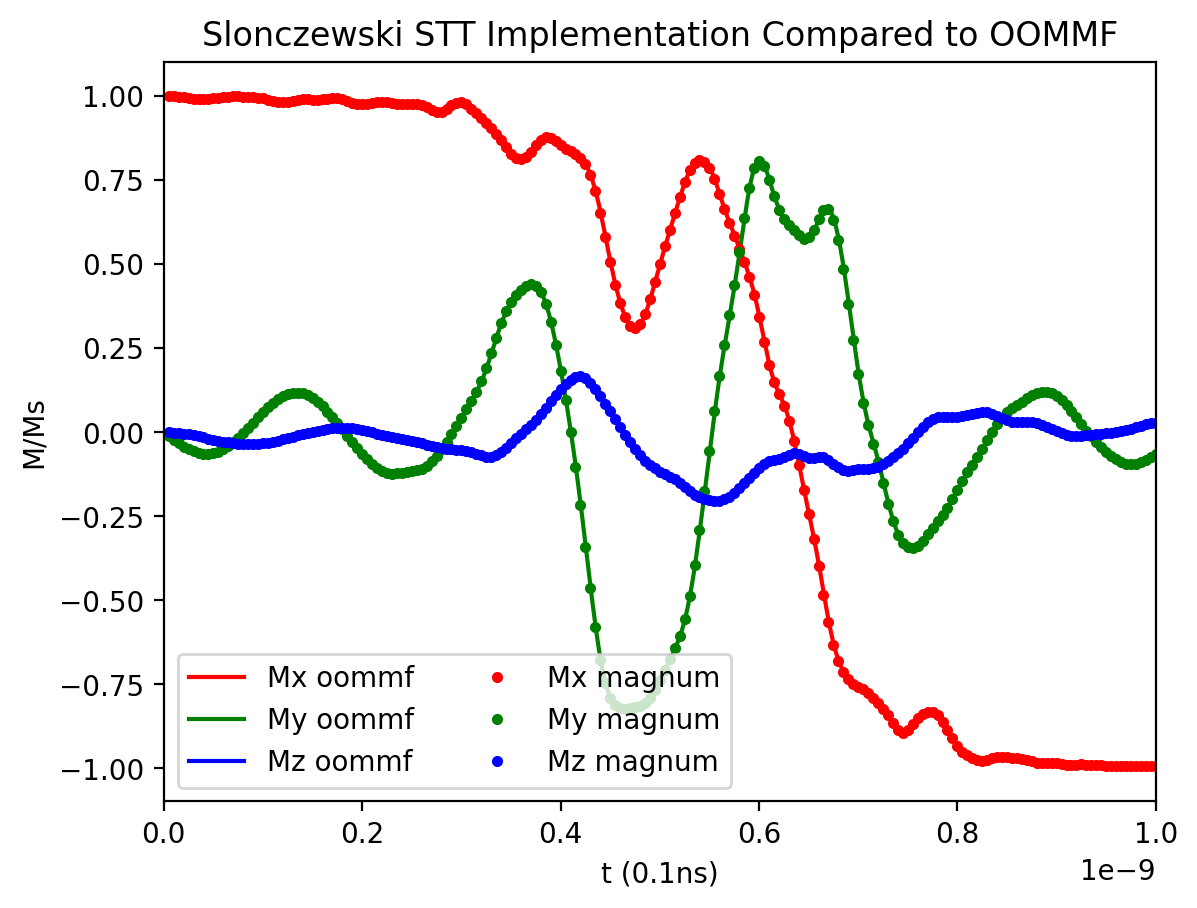

In [5]:
M_mx3 = np.load("ref/M_mx3_2.npy")
M_oommf = np.load("ref/M_oommf_2.npy")

plt.plot(M_oommf[0], M_oommf[1], "r-", label="Mx oommf")
plt.plot(M_oommf[0], M_oommf[2], "g-", label="My oommf")
plt.plot(M_oommf[0], M_oommf[3], "b-", label="Mz oommf")


plt.plot(t, mx, "r.", label="Mx magnum")
plt.plot(t, my, "g.", label="My magnum")
plt.plot(t, mz, "b.", label="Mz magnum")

plt.legend(ncol=2)
plt.xlim(0, 1e-9)
plt.xlabel("t (0.1ns)")
plt.ylabel("M/Ms")
plt.title("Slonczewski STT Implementation Compared to OOMMF")
# plt.savefig("oommf_1.png", dpi=300)
plt.show()

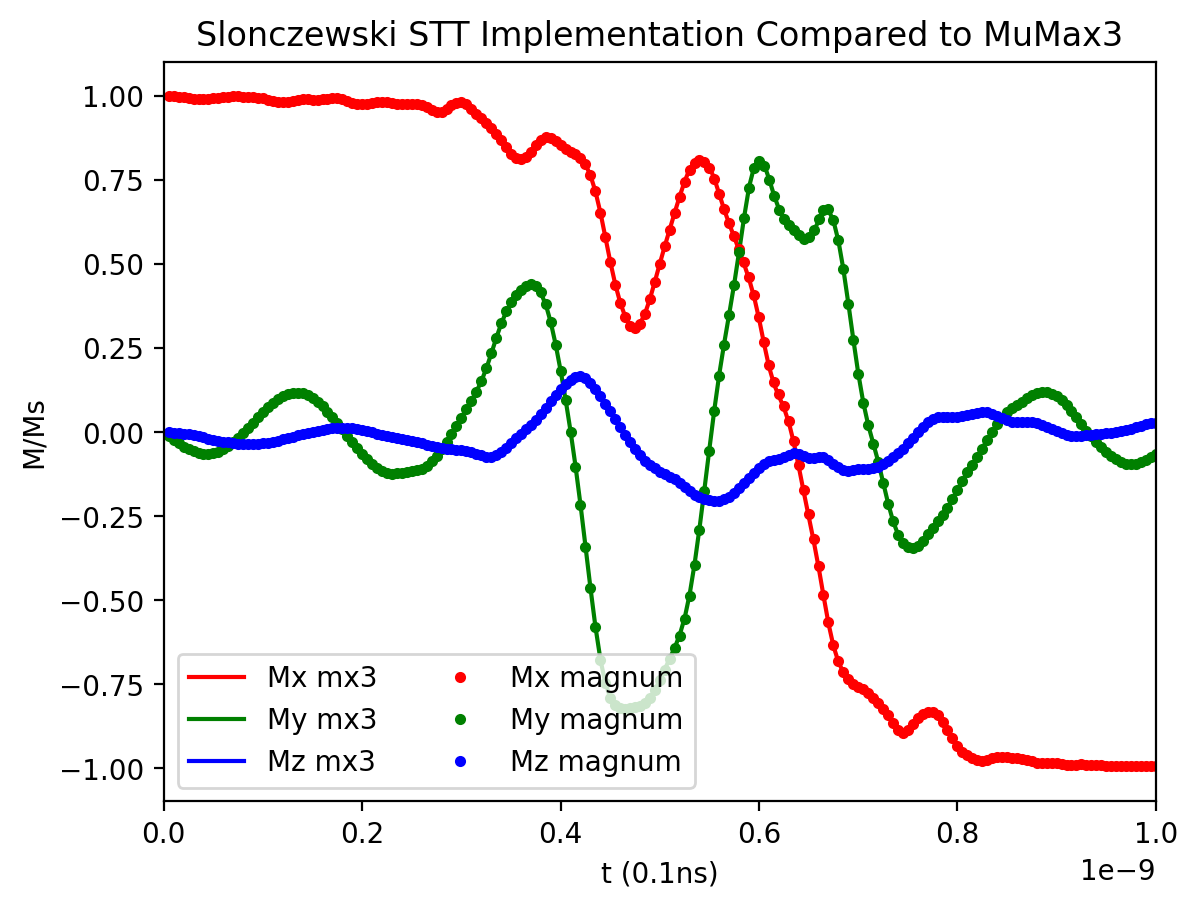

In [6]:
plt.plot(M_mx3[0], M_mx3[1], "r-", label="Mx mx3")
plt.plot(M_mx3[0], M_mx3[2], "g-", label="My mx3")
plt.plot(M_mx3[0], M_mx3[3], "b-", label="Mz mx3")

plt.plot(t, mx, "r.", label="Mx magnum")
plt.plot(t, my, "g.", label="My magnum")
plt.plot(t, mz, "b.", label="Mz magnum")

plt.legend(ncol=2)
plt.xlim(0, 1e-9)
plt.xlabel("t (0.1ns)")
plt.ylabel("M/Ms")
plt.title("Slonczewski STT Implementation Compared to MuMax3")
# plt.savefig("mx3_1.png", dpi=300)
plt.show()